# Telecom Multinomial Logistic Regression


## Outline

-Data Loading & Parsing
- Feature Engineering
- Check VIF
- Full Model
  -*Summary Chart and Bootstrap*
-Elastic Net on Full Model
  - *Summary Chart and Bootstrap*
-Reduced Model After Drop Using VIF
  - *Summary Chart and Bootstrap*

**Supplemental**

8 Logistic Regression for Each Class
  - *Summary Chart and Bootstrap*



## 1. Data Loading & Parsing

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_val_predict, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

### Import Data

In [2]:
# Import Data from Drive
telecom = pd.read_json(r"C:\Users\Megan Huy\Documents\DSSP\train.json")

In [3]:
# Split Text Column
split_cols = telecom['question'].str.split('|', expand=True)

### Parse Question Column

In [4]:
def parse_question(question):
    drive_marker       = "User plane drive test data as follows："
    engineering_marker = "Engeneering parameters data as follows："

    drive_section      = question.split(drive_marker, 1)[1]
    drive_table_text   = drive_section.split(engineering_marker, 1)[0].strip()
    engineering_table_text = question.split(engineering_marker, 1)[1].strip()

    drive_df       = pd.read_csv(StringIO(drive_table_text), sep="|")
    engineering_df = pd.read_csv(StringIO(engineering_table_text), sep="|")

    return drive_df, engineering_df

### Define Column Names

In [5]:
timestamp    = "Timestamp"
speed        = "GPS Speed (km/h)"
serving_pci  = "5G KPI PCell RF Serving PCI"
serving_rsrp = "5G KPI PCell RF Serving SS-RSRP [dBm]"
serving_sinr = "5G KPI PCell RF Serving SS-SINR [dB]"
throughput   = "5G KPI PCell Layer2 MAC DL Throughput [Mbps]"
rb           = "5G KPI PCell Layer1 DL RB Num (Including 0)"

neighbor_pci_group = [
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI",
]

neighbor_rsrp_group = [
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]",
]

### Clean Data Functions

In [6]:
def clean_drive_data(drive_df):
    drive_df = drive_df.rename(columns=lambda x: x.strip())
    drive_df[timestamp] = pd.to_datetime(drive_df[timestamp], errors="coerce")

    drive_numeric_cols = [
        "Longitude", "Latitude", speed, serving_pci,
        serving_rsrp, serving_sinr, throughput, rb,
    ] + neighbor_pci_group + neighbor_rsrp_group

    for col in drive_numeric_cols:
        drive_df[col] = (
            drive_df[col].replace("-", np.nan).replace("", np.nan)
        )
        drive_df[col] = pd.to_numeric(drive_df[col], errors="coerce")

    return drive_df


def clean_engineering_data(engineering_df):
    engineering_df = engineering_df.rename(columns=lambda x: x.strip())

    engineering_numeric_cols = [
        "PCI", "Longitude", "Latitude",
        "Mechanical Downtilt", "Digital Tilt", "Height",
    ]

    for col in engineering_numeric_cols:
        engineering_df[col] = (
            engineering_df[col].replace("-", np.nan).replace("", np.nan)
        )
        engineering_df[col] = pd.to_numeric(engineering_df[col], errors="coerce")

    # Digital Tilt rule: 255 means 6 degrees
    engineering_df["digital_tilt_normalized"] = np.where(
        engineering_df["Digital Tilt"] == 255,
        6,
        engineering_df["Digital Tilt"]
    )

    return engineering_df

---
## 2. Feature Engineering

### Helpers & Constants

In [ ]:
#Average Distance Helper

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def _max_consecutive_true(series: pd.Series) -> int:
    """Longest consecutive run of True in a boolean series."""
    max_run = cur_run = 0
    for val in series:
        if val:
            cur_run += 1
            max_run = max(max_run, cur_run)
        else:
            cur_run = 0
    return max_run


BEAM_SCENARIO_BEAMWIDTH = {"3D": 6, "Wide": 25, "Medium": 12}

LOW_TP_THRESHOLD     = 600   # Mbps
SPEED_THRESHOLD      = 40    # km/h
RB_THRESHOLD         = 160
NEAR_NEIGHBOR_DB     = 3     # dB
DISTANCE_KM_THRESHOLD = 1.0

### Engineer Features Function

In [8]:
def engineer_features(drive_df, engineering_df):
    drive_df       = clean_drive_data(drive_df)
    engineering_df = clean_engineering_data(engineering_df)

    engineering_join = engineering_df.rename(columns={"PCI": "engineering_pci"})
    merged_df = drive_df.merge(
        engineering_join, left_on=serving_pci,
        right_on="engineering_pci", how="left"
    )

    # Distance & tilt
    merged_df["serving_distance_km_row"] = haversine_distance(
        merged_df["Latitude_x"], merged_df["Longitude_x"],
        merged_df["Latitude_y"], merged_df["Longitude_y"],
    )
    merged_df["effective_tilt_row"] = (
        merged_df["Mechanical Downtilt"] + merged_df["digital_tilt_normalized"]
    )
    merged_df["beamwidth_row"] = (
        merged_df["Beam Scenario"].map(BEAM_SCENARIO_BEAMWIDTH).fillna(np.nan)
    )

    # Throughput flag
    low_tp_mask = merged_df[throughput] < LOW_TP_THRESHOLD

    # Neighbor features
    merged_df["best_neighbor_rsrp_row"] = merged_df[neighbor_rsrp_group].max(axis=1)
    merged_df["neighbor_advantage_row"] = (
        merged_df["best_neighbor_rsrp_row"] - merged_df[serving_rsrp]
    )
    close_neighbor_matrix = merged_df[neighbor_rsrp_group].apply(
        lambda col: (col - merged_df[serving_rsrp]).abs() <= NEAR_NEIGHBOR_DB
    )
    merged_df["close_neighbor_count_row"] = close_neighbor_matrix.sum(axis=1)
    merged_df["neighbor_stronger_row"] = (
        merged_df["best_neighbor_rsrp_row"] > merged_df[serving_rsrp]
    ).astype(int)

    # PCI mod-30 conflict
    serving_mod30 = merged_df[serving_pci] % 30
    mod30_conflict_matrix = pd.concat(
        [(merged_df[pci] % 30 == serving_mod30).fillna(False) for pci in neighbor_pci_group],
        axis=1,
    )
    merged_df["mod30_conflict_row"] = mod30_conflict_matrix.any(axis=1).astype(int)
    merged_df["mod30_count_row"]    = mod30_conflict_matrix.sum(axis=1)

    # Flag columns
    merged_df["speed_above_40_row"] = (merged_df[speed] > SPEED_THRESHOLD).astype(int)
    merged_df["rb_below_160_row"]   = (merged_df[rb] < RB_THRESHOLD).astype(int)
    merged_df["sinr_below_5_row"]   = (merged_df[serving_sinr] < 5).astype(int)

    # Handover
    merged_df = merged_df.sort_values(timestamp).reset_index(drop=True)
    merged_df["handover_flag"] = (
        merged_df[serving_pci] != merged_df[serving_pci].shift(1)
    ).astype(int)
    if len(merged_df) > 0:
        merged_df.loc[0, "handover_flag"] = 0

    n_rows = len(merged_df)
    handover_rate_denom = max(n_rows - 1, 1)

    low_tp_count = int(low_tp_mask.sum())

    def _low_tp_mean(col):
        return merged_df.loc[low_tp_mask, col].mean() if low_tp_count > 0 else np.nan
    def _low_tp_max(col):
        return merged_df.loc[low_tp_mask, col].max() if low_tp_count > 0 else np.nan
    def _low_tp_min(col):
        return merged_df.loc[low_tp_mask, col].min() if low_tp_count > 0 else np.nan

    handover_count = int(merged_df["handover_flag"].sum())

    handover_count_low_tp = 0
    if low_tp_count > 0:
        low_tp_pci = merged_df.loc[low_tp_mask, serving_pci]
        handover_count_low_tp = max(int((low_tp_pci != low_tp_pci.shift(1)).sum() - 1), 0)

    avg_neighbor_advantage  = merged_df["neighbor_advantage_row"].mean()
    overlap_ratio           = (merged_df["close_neighbor_count_row"] > 0).mean()
    avg_sinr                = merged_df[serving_sinr].mean()
    avg_serving_tilt        = merged_df["effective_tilt_row"].mean()
    min_rsrp                = merged_df[serving_rsrp].min()

    txrx_mode = (
        merged_df["TxRx Mode"].mode().iloc[0]
        if "TxRx Mode" in merged_df.columns and not merged_df["TxRx Mode"].isna().all()
        else "Unknown"
    )
    antenna_model = (
        merged_df["Antenna Model"].mode().iloc[0]
        if "Antenna Model" in merged_df.columns and not merged_df["Antenna Model"].isna().all()
        else "Unknown"
    )

    feature_dict = {
        # Throughput
        "avg_throughput":         merged_df[throughput].mean(),
        "min_throughput":         merged_df[throughput].min(),
        "std_throughput":         merged_df[throughput].std(),
        "low_tp_count":           low_tp_count,
        "low_tp_ratio":           low_tp_mask.mean(),
        "avg_throughput_low_tp":  _low_tp_mean(throughput),
        "consecutive_low_tp_max": _max_consecutive_true(low_tp_mask),
        # Speed
        "max_speed":              merged_df[speed].max(),
        "pct_speed_above_40":     merged_df["speed_above_40_row"].mean(),
        "avg_speed_low_tp":       _low_tp_mean(speed),
        "max_speed_low_tp":       _low_tp_max(speed),
        # Mobility
        "num_unique_serving_pci": merged_df[serving_pci].nunique(),
        "handover_count":         handover_count,
        "handover_rate":          handover_count / handover_rate_denom,
        "handover_count_low_tp":  handover_count_low_tp,
        # RSRP
        "avg_rsrp":               merged_df[serving_rsrp].mean(),
        "min_rsrp":               min_rsrp,
        "avg_rsrp_low_tp":        _low_tp_mean(serving_rsrp),
        # SINR
        "avg_sinr":               avg_sinr,
        "min_sinr":               merged_df[serving_sinr].min(),
        "std_sinr":               merged_df[serving_sinr].std(),
        "pct_sinr_below_5":       merged_df["sinr_below_5_row"].mean(),
        "avg_sinr_low_tp":        _low_tp_mean(serving_sinr),
        "min_sinr_low_tp":        _low_tp_min(serving_sinr),
        # RB
        "avg_rb":                 merged_df[rb].mean(),
        "min_rb":                 merged_df[rb].min(),
        "avg_rb_low_tp":          _low_tp_mean(rb),
        "min_rb_low_tp":          _low_tp_min(rb),
        "pct_rb_below_160":       merged_df["rb_below_160_row"].mean(),
        # Neighbor signal
        "avg_neighbor_advantage":  avg_neighbor_advantage,
        "max_neighbor_advantage":  merged_df["neighbor_advantage_row"].max(),
        "neighbor_stronger_ratio": merged_df["neighbor_stronger_row"].mean(),
        "avg_close_neighbor_count":merged_df["close_neighbor_count_row"].mean(),
        "overlap_ratio":           overlap_ratio,
        # PCI mod-30
        "same_mod30_exists":      int(merged_df["mod30_conflict_row"].any()),
        "same_mod30_count":       int(merged_df["mod30_count_row"].sum()),
        "same_mod30_ratio":       merged_df["mod30_conflict_row"].mean(),
        # Serving-cell engineering
        "avg_serving_tilt":        avg_serving_tilt,
        "max_serving_tilt":        merged_df["effective_tilt_row"].max(),
        "avg_serving_beamwidth":   merged_df["beamwidth_row"].mean(),
        "avg_serving_height":      merged_df["Height"].mean(),
        "avg_serving_distance_km": merged_df["serving_distance_km_row"].mean(),
        "max_serving_distance_km": merged_df["serving_distance_km_row"].max(),
        "pct_distance_gt_1km":     (merged_df["serving_distance_km_row"] > DISTANCE_KM_THRESHOLD).mean(),
        "avg_distance_low_tp":     _low_tp_mean("serving_distance_km_row"),
        # Categorical
        "txrx_mode":              txrx_mode,
        "antenna_model":          antenna_model,
        # Interaction / derived
        "throughput_per_sinr":    merged_df[throughput].mean() / (avg_sinr + 1) if pd.notna(avg_sinr) else np.nan,
        "tilt_rsrp_interaction":  avg_serving_tilt * abs(min_rsrp) if pd.notna(min_rsrp) else np.nan,
        "neighbor_competition":   avg_neighbor_advantage * overlap_ratio,
    }

    return feature_dict

### Build Feature DataFrame

In [9]:
features = []

for idx, row in telecom.iterrows():
    drive_df, engineering_df = parse_question(row["question"])
    feature_dict = engineer_features(drive_df, engineering_df)
    feature_dict["answer"]     = row["answer"]
    feature_dict["row_number"] = idx
    features.append(feature_dict)

new_feature_df = pd.DataFrame(features)
print(new_feature_df.shape)
new_feature_df.head()

(2400, 52)


,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,txrx_mode,antenna_model,throughput_per_sinr,tilt_rsrp_interaction,neighbor_competition,answer,row_number
0,847.792,334.00,407.163069,4,0.4,424.7125,4,33,0.0,12.75,...,2.774421,0.4,2.771672,64T64R,NR AAU 2,64.925103,1164.372,-1.7334,C2,0
1,850.051,388.58,345.211857,4,0.4,470.3825,4,33,0.0,12.75,...,0.068577,0.0,0.044401,32T32R,NR AAU 1,69.579357,2445.844,-0.0000,C1,1
2,671.739,258.08,295.071300,4,0.4,338.5225,4,36,0.0,16.00,...,1.698408,0.4,1.698408,32T32R,NR AAU 3,30.204092,1671.780,-0.0000,C2,2
3,921.430,407.35,399.562308,4,0.4,459.8275,4,32,0.0,8.75,...,2.976701,0.4,2.957331,64T64R,NR AAU 2,78.768165,1090.680,-0.0000,C2,3
4,789.406,319.87,366.988478,4,0.4,404.2275,4,32,0.0,22.75,...,0.263115,0.0,0.183851,32T32R,NR AAU 1,71.712028,1196.300,-1.4376,C5,4


### One-Hot Encode Engineering Categorical Columns

In [10]:
all_engineering_tables = []

for i in range(len(telecom)):
    question = telecom.loc[i, "question"]
    drive_df, engineering_df = parse_question(question)
    engineering_df["row_number"] = i
    all_engineering_tables.append(engineering_df)

all_engineering = pd.concat(all_engineering_tables, ignore_index=True)

cat_cols = ["Beam Scenario", "TxRx Mode", "Antenna Model"]
all_engineering_encoded = pd.get_dummies(all_engineering, columns=cat_cols, dtype=int)

one_hot_cols = [c for c in all_engineering_encoded.columns if c not in all_engineering.columns]
one_hot_by_question = (
    all_engineering_encoded.groupby("row_number")[one_hot_cols].max().reset_index()
)

final_df = new_feature_df.merge(one_hot_by_question, on="row_number", how="left")
final_df = final_df.drop(columns=["row_number"], errors="ignore")

cols = final_df.columns.tolist()
cols.remove("answer")
cols.insert(0, "answer")
final_df = final_df[cols]

print(final_df.shape)
final_df.head()

(2400, 72)


,answer,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,...,Beam Scenario_SCENARIO_9,TxRx Mode_2T2R,TxRx Mode_32T32R,TxRx Mode_4T4R,TxRx Mode_64T64R,TxRx Mode_8T8R,Antenna Model_NR AAU 1,Antenna Model_NR AAU 2,Antenna Model_NR AAU 3,Antenna Model_Other
0,C2,847.792,334.00,407.163069,4,0.4,424.7125,4,33,0.0,...,1,0,1,0,1,0,1,1,0,0
1,C1,850.051,388.58,345.211857,4,0.4,470.3825,4,33,0.0,...,1,0,1,1,1,0,1,1,0,1
2,C2,671.739,258.08,295.071300,4,0.4,338.5225,4,36,0.0,...,1,0,1,0,1,0,0,1,1,0
3,C2,921.430,407.35,399.562308,4,0.4,459.8275,4,32,0.0,...,1,0,1,1,1,0,0,1,1,1
4,C5,789.406,319.87,366.988478,4,0.4,404.2275,4,32,0.0,...,0,0,1,0,1,0,1,1,1,0


---
## 3. Check VIF

### Compute VIF on All Numeric Features

In [11]:
X = final_df.drop(columns=["answer"])
X = X.drop(columns=["txrx_mode", "antenna_model"], errors="ignore")
X_numeric = X.select_dtypes(include=[np.number])
X_numeric = X_numeric.fillna(X_numeric.median()).fillna(0)
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)
X_numeric = X_numeric.loc[:, X_numeric.nunique() > 1]

X_const = add_constant(X_numeric)

vif_df = pd.DataFrame({
    "Feature": X_const.columns,
    "VIF": [
        variance_inflation_factor(X_const.values, i)
        for i in range(X_const.shape[1])
    ]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"Features with VIF >= 10: {len(vif_df[vif_df['VIF'] >= 10])}")
vif_df

Features with VIF >= 10: 39


,Feature,VIF
0,num_unique_serving_pci,inf
1,handover_count,inf
2,low_tp_count,inf
3,low_tp_ratio,inf
4,pct_distance_gt_1km,inf
...,...,...
61,Beam Scenario_SCENARIO_7,1.539291
62,Beam Scenario_SCENARIO_2,1.529200
63,Beam Scenario_SCENARIO_14,1.269094
64,throughput_per_sinr,1.131505


### Iterative VIF Removal (Threshold = 10)

In [12]:
def iterative_vif_removal(X, threshold=10):
    cols    = list(X.columns)
    dropped = []

    while True:
        X_const    = add_constant(pd.DataFrame(X[cols]))
        vif_series = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns
        ).drop("const")

        max_vif = vif_series.max()
        if max_vif < threshold:
            break

        worst = vif_series.idxmax()
        dropped.append((worst, round(max_vif, 2)))
        cols.remove(worst)
        print(f"Dropped: {worst} (VIF={max_vif:.2f}) — {len(cols)} features remaining")

    print(f"\nDone. {len(cols)} kept, {len(dropped)} dropped.")
    return X[cols], dropped


X_vif_clean, dropped_features = iterative_vif_removal(X_numeric)

Dropped: low_tp_count (VIF=inf) — 64 features remaining
Dropped: num_unique_serving_pci (VIF=inf) — 63 features remaining
Dropped: handover_count (VIF=inf) — 62 features remaining
Dropped: tilt_rsrp_interaction (VIF=2231.63) — 61 features remaining
Dropped: max_serving_distance_km (VIF=727.81) — 60 features remaining
Dropped: avg_rb_low_tp (VIF=259.82) — 59 features remaining
Dropped: avg_distance_low_tp (VIF=149.24) — 58 features remaining
Dropped: overlap_ratio (VIF=105.80) — 57 features remaining
Dropped: min_sinr_low_tp (VIF=88.34) — 56 features remaining
Dropped: avg_sinr (VIF=70.74) — 55 features remaining
Dropped: avg_throughput (VIF=56.12) — 54 features remaining
Dropped: pct_distance_gt_1km (VIF=46.41) — 53 features remaining
Dropped: low_tp_ratio (VIF=34.71) — 52 features remaining
Dropped: min_sinr (VIF=34.18) — 51 features remaining
Dropped: Antenna Model_Other (VIF=30.75) — 50 features remaining
Dropped: avg_rb (VIF=24.83) — 49 features remaining
Dropped: same_mod30_ratio 

### Comment

24 variables were dropped. 41 Variables are kept.

### Verify VIF After Cleaning

In [13]:
X_recheck      = X_vif_clean.fillna(X_vif_clean.median()).fillna(0)
X_recheck      = X_recheck.replace([np.inf, -np.inf], np.nan).fillna(0)
X_recheck      = X_recheck.loc[:, X_recheck.nunique() > 1]
X_const_re     = add_constant(X_recheck)

vif_recheck = pd.DataFrame({
    "Feature": X_const_re.columns,
    "VIF": [
        variance_inflation_factor(X_const_re.values, i)
        for i in range(X_const_re.shape[1])
    ]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"Features with VIF >= 10 after cleaning: {len(vif_recheck[vif_recheck['VIF'] >= 10])}")
vif_recheck

Features with VIF >= 10 after cleaning: 1


,Feature,VIF
0,const,4421.698127
1,min_rb,8.236360
2,pct_rb_below_160,7.928927
3,avg_rsrp,7.002270
4,avg_serving_tilt,6.839922
5,pct_speed_above_40,6.616159
6,max_speed_low_tp,6.426337
7,max_serving_tilt,5.899266
8,avg_rsrp_low_tp,5.074743
9,avg_sinr_low_tp,4.551578


### Comment

After dropping the features with VIF of >10, we have features that show moderate (5-9), low (1-4), or no multicollinearity.

---
## 4. Full Model

Full Multinomial Logistic Regression on all features (no VIF drop).

In [21]:
y = final_df["answer"]

X_full = final_df.drop(columns=["answer", "txrx_mode", "antenna_model"], errors="ignore")
X_full = X_full.select_dtypes(include=[np.number])
X_full = X_full.fillna(X_full.median()).fillna(0)
X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0)
X_full = X_full.loc[:, X_full.nunique() > 1]

scaler_full  = StandardScaler()
X_full_scaled = pd.DataFrame(
    scaler_full.fit_transform(X_full), columns=X_full.columns
)

clf_full = LogisticRegression(
    multi_class="multinomial", solver="lbfgs",
    max_iter=5000, C=1.0, random_state=123
)
clf_full.fit(X_full_scaled, y)

coef_full = pd.DataFrame(clf_full.coef_, index=clf_full.classes_, columns=X_full.columns).T
odds_full = np.exp(coef_full)

print("=== Full Model: Coefficients ===")
print(coef_full)
print("\n=== Full Model: Odds Ratios ===")
pd.set_option("display.max_rows", None)
print(odds_full)

=== Full Model: Coefficients ===
                              C1        C2        C3        C4        C5  \
avg_throughput         -0.389450  0.012146  0.375990 -0.246378  0.002257   
min_throughput          0.984217  0.045022 -2.196513  0.802585  0.047289   
std_throughput          0.301282  0.045568 -1.217020  0.449999  0.077096   
low_tp_count            0.013606  0.007163 -0.170731  0.179080 -0.093014   
low_tp_ratio            0.013606  0.007163 -0.170731  0.179080 -0.093014   
...                          ...       ...       ...       ...       ...   
TxRx Mode_4T4R          0.448904 -0.007742 -0.065313 -0.305260  0.023123   
TxRx Mode_8T8R          0.220012 -0.052975  0.139916 -0.301775 -0.064638   
Antenna Model_NR AAU 1 -0.133758 -0.043725 -0.083019  0.245296 -0.000568   
Antenna Model_NR AAU 3 -0.159363  0.003620  0.021619  0.177324 -0.047531   
Antenna Model_Other     0.914329 -0.036443 -0.811747  0.109872 -0.012572   

                              C6        C7        C8  

### 4a. Summary Chart and Bootstrap — Full Model

#### Statsmodels MNLogit Summary

In [15]:
X_sm_full = sm.add_constant(X_full_scaled)

mnlogit_full = sm.MNLogit(y, X_sm_full)
mnlogit_full_results = mnlogit_full.fit(maxiter=500, method="newton", disp=False)

print(mnlogit_full_results.summary())

                          MNLogit Regression Results                          
Dep. Variable:                 answer   No. Observations:                 2400
Model:                        MNLogit   Df Residuals:                     1959
Method:                           MLE   Df Model:                          434
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                     nan
Time:                        13:42:24   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -4966.6
Covariance Type:            nonrobust   LLR p-value:                       nan
                      answer=C2       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                                  nan        nan        nan        nan         nan         nan
avg_throughput                         nan        nan        nan    

### Comment

The MNLogit summary cannot produce coefficients, standard errors, CIs, or p-values due to perfect/near-perfect separation and multicollinearity across the 65 features, preventing inference.

Try Bootstrap to provide mean coefficients, standard deviation (as a proxy for standard error), 95% CIs, and significance flags. Bootstrap results are used as the primary basis for inference throughout this analysis.

#### Bootstrap — Full Model

In [43]:
def bootstrap_summary(clf_fitted, X_scaled, X_cols, y, n_bootstraps=500, random_state=0):
    classes       = list(clf_fitted.classes_)
    feature_names = list(X_cols)
    params        = clf_fitted.get_params()
    solver        = params["solver"]
    penalty       = params["penalty"]
    l1_ratio      = params.get("l1_ratio", None)
    C             = params["C"]

    coef_boots = []
    for i in range(n_bootstraps):
        X_b, y_b = resample(X_scaled, y, random_state=random_state + i, stratify=y)

        if l1_ratio is not None:
            clf_b = LogisticRegression(
                multi_class="multinomial", solver=solver, penalty=penalty,
                l1_ratio=l1_ratio, max_iter=5000, C=C, random_state=123
            )
        else:
            clf_b = LogisticRegression(
                multi_class="multinomial", solver=solver, penalty=penalty,
                max_iter=5000, C=C, random_state=123
            )
        clf_b.fit(X_b, y_b)

        coef_aligned = (
            pd.DataFrame(clf_b.coef_, index=clf_b.classes_, columns=feature_names)
            .reindex(classes).values
        )
        coef_boots.append(coef_aligned)

    coef_boots = np.array(coef_boots)
    coef_mean  = coef_boots.mean(axis=0)
    coef_lower = np.percentile(coef_boots, 2.5,  axis=0)
    coef_upper = np.percentile(coef_boots, 97.5, axis=0)

    summaries = {}
    for i, cls in enumerate(classes):
        df = pd.DataFrame({
            "Feature":     feature_names,
            "Coef":        coef_mean[i].round(4),
            "Lower_95":    coef_lower[i].round(4),
            "Upper_95":    coef_upper[i].round(4),
            "OddsRatio":   np.exp(coef_mean[i]).round(4),
            "Significant": ~((coef_lower[i] < 0) & (coef_upper[i] > 0))
        }).sort_values("Coef", key=abs, ascending=False).reset_index(drop=True)
        summaries[cls] = df
    return summaries


def print_bootstrap_summary(summaries, model_name):
    print("\n" + "="*70)
    print(f"{model_name} — Bootstrap Summary")
    print("="*70)
    for cls, df in summaries.items():
        print(f"\n--- Class {cls} ---")
        print(df.to_string(index=False))


print("Running bootstrap for Full Model...")
boot_full = bootstrap_summary(clf_full, X_full_scaled, X_full.columns, y)
print_bootstrap_summary(boot_full, "Full Model (All Features)")

Running bootstrap for Full Model...

Full Model (All Features) — Bootstrap Summary

--- Class C1 ---
                        Feature    Coef  Lower_95  Upper_95  OddsRatio  Significant
         avg_neighbor_advantage -1.5057   -2.0357   -0.9198     0.2219         True
             avg_serving_height -1.4269   -1.8722   -0.9922     0.2401         True
                       min_rsrp -1.3298   -1.7310   -1.0036     0.2645         True
Beam Scenario_EXPAND_SCENARIO_2 -1.1720   -1.6579   -0.6459     0.3097         True
           neighbor_competition  1.0808    0.6718    1.4806     2.9471         True
          avg_throughput_low_tp -0.9902   -1.5775   -0.3933     0.3715         True
                 min_throughput  0.9297    0.3200    1.4883     2.5338         True
            Antenna Model_Other  0.8338    0.1013    1.5191     2.3021         True
                       avg_sinr -0.7593   -1.3671   -0.1289     0.4680         True
                       avg_rsrp -0.7270   -1.3673   -0.2208

#### Coefficient Plot — Full Model (Top 10 per Class)

In [ ]:
def plot_coef_summary(summaries, model_name, top_n=10):
    classes = list(summaries.keys())
    n_cls   = len(classes)
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)
    fig.suptitle(f"{model_name} — Top {top_n} Features per Class (Bootstrap Mean ± 95% CI)", fontsize=13)

    for ax, cls in zip(axes.flat, classes):
        df  = summaries[cls].head(top_n).iloc[::-1]
        colors = ["#3cabe7" if s else "#95a5a6" for s in df["Significant"]]
        ax.barh(df["Feature"], df["Coef"], xerr=[df["Coef"] - df["Lower_95"], df["Upper_95"] - df["Coef"]],
                color=colors, capsize=3, ecolor="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"Class {cls}", fontsize=10)
        ax.tick_params(axis="y", labelsize=7)

    for ax in axes.flat[n_cls:]:
        ax.set_visible(False)

    plt.savefig("full_model_coef_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved: full_model_coef_plot.png")

def plot_coef_summary(summaries, model_name, top_n=10, color="#2E86AB"):
    classes = list(summaries.keys())
    n_cls   = len(classes)
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)
    fig.suptitle(f"{model_name} — Top {top_n} Features per Class (Bootstrap Mean ± 95% CI)", fontsize=13)

    for ax, cls in zip(axes.flat, classes):
        df     = summaries[cls].head(top_n).iloc[::-1]
        colors = [color if s else "#95a5a6" for s in df["Significant"]]
        ax.barh(df["Feature"], df["Coef"], xerr=[df["Coef"] - df["Lower_95"], df["Upper_95"] - df["Coef"]],
                color=colors, capsize=3, ecolor="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"Class {cls}", fontsize=10)
        ax.tick_params(axis="y", labelsize=7)

    for ax in axes.flat[n_cls:]:
        ax.set_visible(False)

    plt.savefig("full_model_coef_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved: full_model_coef_plot.png")


plot_coef_summary(boot_full, "Full Model", color="#2E86AB")

---
## 5. Elastic Net on Full Model

In [ ]:
clf_enet = LogisticRegression(
    multi_class="multinomial", solver="saga",
    penalty="elasticnet", l1_ratio=0.5,
    max_iter=5000, C=1.0, random_state=123
)
clf_enet.fit(X_full_scaled, y)

coef_enet = pd.DataFrame(clf_enet.coef_, index=clf_enet.classes_, columns=X_full.columns).T
odds_enet = np.exp(coef_enet)

print("=== Elastic Net: Coefficients (All Features) ===")
print(coef_enet)
print("\n=== Elastic Net: Odds Ratios ===")
print(odds_enet)

=== Elastic Net: Coefficients (All Features) ===
                              C1   C2        C3        C4        C5        C6  \
avg_throughput         -0.115273  0.0  0.346458 -0.027671  0.000000  0.000000   
min_throughput          0.520571  0.0 -2.682982  0.274466  0.000000  0.000000   
std_throughput          0.000000  0.0 -1.333628  0.163446  0.000000  0.330828   
low_tp_count            0.000000  0.0 -0.251319  0.195162 -0.013363  0.000000   
low_tp_ratio            0.000000  0.0 -0.251319  0.195162 -0.013363  0.000000   
...                          ...  ...       ...       ...       ...       ...   
TxRx Mode_4T4R          0.384667  0.0  0.000000 -0.048342  0.000000 -0.061398   
TxRx Mode_8T8R          0.050716  0.0  0.017258 -0.325401  0.000000  0.000000   
Antenna Model_NR AAU 1 -0.059645  0.0 -0.042982  0.221076  0.000000  0.027220   
Antenna Model_NR AAU 3 -0.120239  0.0  0.000000  0.129186  0.000000  0.000000   
Antenna Model_Other     0.955267  0.0 -0.713488  0.013439  0

Elastic net was applied to the full 65-feature model as an alternative to manual VIF cleaning, using L1+L2 regularization (l1_ratio=0.5) to perform automatic feature selection.

However, C2, C5, C7, and C8 are fully zeroed out — all coefficients = 0, all odds ratios = 1.0. Multicollinearity causes the L1 penalty to zero out entire correlated feature groups, eliminating the class signal entirely.

This confirms that elastic net alone is not a substitute for VIF cleaning. The reduced model (VIF-cleaned) is used as the primary model for inference.

### 5a. Summary Chart and Bootstrap — Elastic Net

#### Nonzero Coefficients per Class

In [23]:
nonzero = (coef_enet != 0).sum()
print("Nonzero coefficients per class:")
print(nonzero.to_string())

Nonzero coefficients per class:
C1    48
C2    10
C3    50
C4    48
C5     6
C6    22
C7     4
C8     5


---
## 6. Reduced Model

Full Multinomial Logistic Regression on VIF-cleaned features.

In [25]:
X_vif = X_vif_clean.copy()
X_vif = X_vif.fillna(X_vif.median()).fillna(0)
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler_vif  = StandardScaler()
X_vif_scaled = pd.DataFrame(
    scaler_vif.fit_transform(X_vif), columns=X_vif.columns
)

clf_reduced = LogisticRegression(
    multi_class="multinomial", solver="lbfgs",
    max_iter=5000, C=1.0, random_state=123
)
clf_reduced.fit(X_vif_scaled, y)

coef_reduced = pd.DataFrame(clf_reduced.coef_, index=clf_reduced.classes_, columns=X_vif.columns).T
odds_reduced = np.exp(coef_reduced)

print("=== Reduced Model: Coefficients (VIF-Cleaned) ===")
print(coef_reduced)
print("\n=== Reduced Model: Odds Ratios ===")
print(odds_reduced)

=== Reduced Model: Coefficients (VIF-Cleaned) ===
                                 C1        C2        C3        C4        C5  \
std_throughput            -0.078280  0.166736 -0.792860  0.210986 -0.013613   
avg_throughput_low_tp     -0.376793 -0.003947  0.603840 -0.380907 -0.021439   
consecutive_low_tp_max     0.364570 -0.060501 -0.545547  0.343850 -0.000637   
pct_speed_above_40        -0.371234 -0.073059 -0.774037 -0.697185 -0.093346   
max_speed_low_tp          -0.775875 -0.146146 -0.448640 -0.345107 -0.159156   
handover_rate             -1.092182  0.772148 -1.236212 -1.325294  3.325864   
avg_rsrp                  -0.650631  0.065021  0.486396 -0.067886  0.025898   
min_rsrp                  -1.326467  0.108982  0.460657  0.407566  0.158400   
avg_rsrp_low_tp            0.053004  0.130526 -0.428026  0.132351 -0.038443   
std_sinr                   0.448886  0.018231 -0.143928 -0.312045  0.017376   
pct_sinr_below_5          -0.164589  0.026938  0.488871 -0.047820  0.052619   
av

### 6a. Summary Chart and Bootstrap — Reduced Model

#### Statsmodels MNLogit Summary

In [26]:
X_sm_vif = sm.add_constant(X_vif_scaled)

mnlogit_vif = sm.MNLogit(y, X_sm_vif)
mnlogit_vif_results = mnlogit_vif.fit(maxiter=500, method="newton", disp=False)

print(mnlogit_vif_results.summary())

                          MNLogit Regression Results                          
Dep. Variable:                 answer   No. Observations:                 2400
Model:                        MNLogit   Df Residuals:                     2106
Method:                           MLE   Df Model:                          287
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                     nan
Time:                        14:28:55   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -4966.6
Covariance Type:            nonrobust   LLR p-value:                       nan
                answer=C2       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                            nan        nan        nan        nan         nan         nan
std_throughput                   nan        nan        nan        nan         nan     

### Comment

Same issue as full model due to class seperation.

In [29]:
print("Running bootstrap for Reduced Model (VIF-Cleaned)...")
boot_reduced = bootstrap_summary(clf_reduced, X_vif_scaled, X_vif.columns, y, n_bootstraps=500)
print_bootstrap_summary(boot_reduced, "Reduced Model (VIF-Cleaned)")

Running bootstrap for Reduced Model (VIF-Cleaned)...

Reduced Model (VIF-Cleaned) — Bootstrap Summary

--- Class C1 ---
                  Feature    Coef  Lower_95  Upper_95  OddsRatio  Significant
       avg_serving_height -1.5122   -1.9691   -1.0763     0.2204         True
                 min_rsrp -1.4889   -1.9074   -1.1442     0.2256         True
         avg_serving_tilt  1.2062    0.6887    1.7870     3.3408         True
            handover_rate -1.1356   -1.3604   -0.9312     0.3212         True
         same_mod30_count -1.0503   -1.5369   -0.5669     0.3498         True
         max_speed_low_tp -0.8123   -1.3672   -0.2158     0.4438         True
         max_serving_tilt  0.7839    0.2060    1.4374     2.1901         True
     neighbor_competition  0.7440    0.3246    1.1660     2.1042         True
                 avg_rsrp -0.6899   -1.3294   -0.1348     0.5016         True
                   min_rb  0.4954   -0.0931    1.0308     1.6412        False
   consecutive_low_tp_

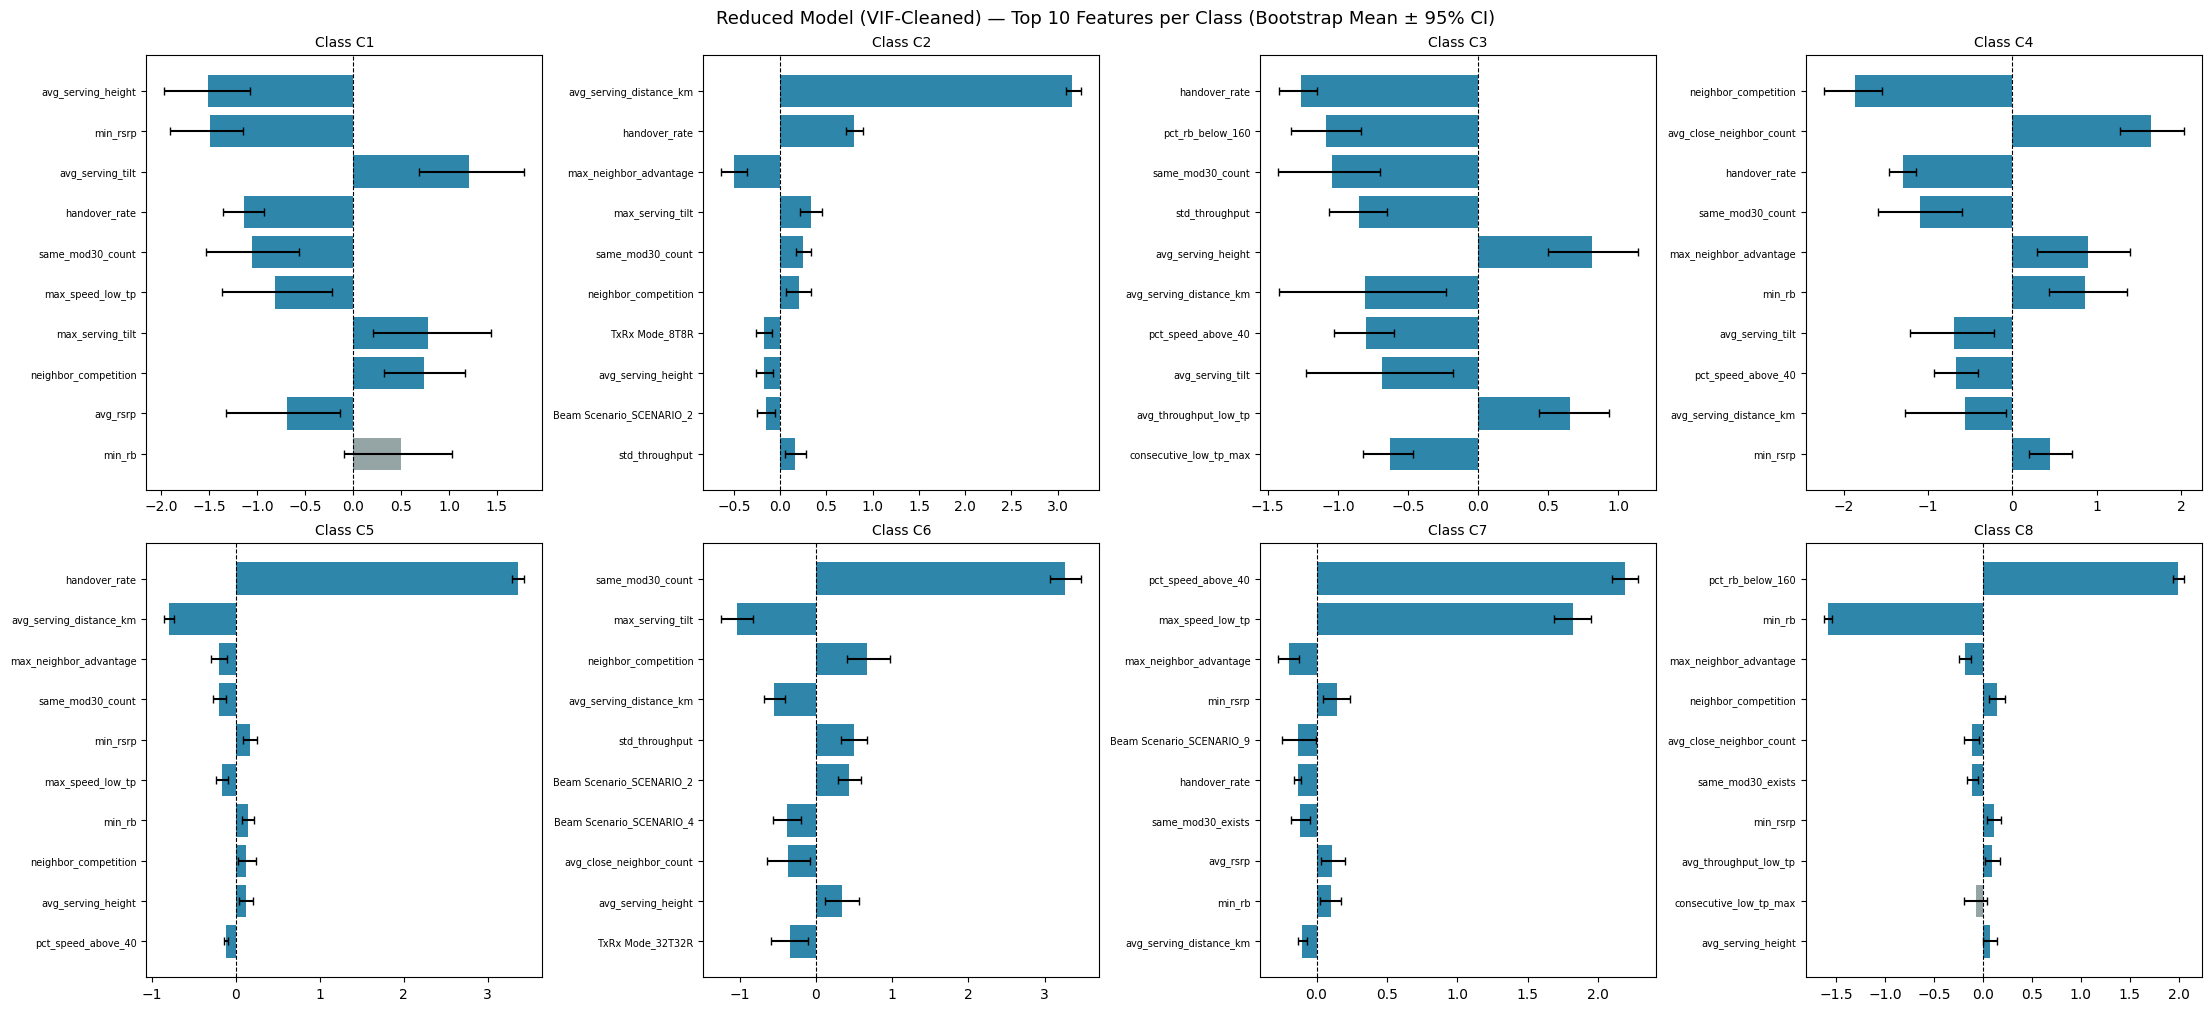

Plot saved: reduced_model_coef_plot.png


In [ ]:
#Plot Mean Coefficients
plot_coef_summary(boot_reduced, "Reduced Model (VIF-Cleaned)", color="#2E86AB")

| Class | Dominant Feature | Dominant OR | Supporting #1 | OR | Supporting #2 | OR | Supporting #3 | OR | Supporting #4 | OR |
|-------|-----------------|-------------|---------------|-----|---------------|-----|---------------|-----|---------------|-----|
| **C1** | `avg_serving_tilt` | 3.34 | `max_serving_tilt` | 2.19 | `neighbor_competition` | 2.10 | `consecutive_low_tp_max` | 1.64 | `min_rb` | 1.64 |
| **C2** | `avg_serving_distance_km` | 23.45 | `handover_rate` | 2.23 | `max_serving_tilt` | 1.39 | `same_mod30_count` | 1.29 | `neighbor_competition` | 1.23 |
| **C3** | `avg_serving_height` | 2.25 | `avg_throughput_low_tp` | 1.93 | `pct_sinr_below_5` | 1.70 | `avg_rsrp` | 1.69 | `min_rsrp` | 1.68 |
| **C4** | `avg_close_neighbor_count` | 5.18 | `max_neighbor_advantage` | 2.44 | `min_rb` | 2.38 | `consecutive_low_tp_max` | 1.44 | `std_throughput` | 1.28 |
| **C5** | `handover_rate` | 28.75 | `min_rsrp` | 1.18 | `min_rb` | 1.16 | `neighbor_competition` | 1.14 | `avg_serving_height` | 1.13 |
| **C6** | `same_mod30_count` | 26.35 | `neighbor_competition` | 1.95 | `std_throughput` | 1.65 | `Beam Scenario_SCENARIO_2` | 1.55 | `avg_serving_height` | 1.42 |
| **C7** | `pct_speed_above_40` | 8.93 | `max_speed_low_tp` | 6.18 | `min_rsrp` | 1.16 | `avg_rsrp` | 1.12 | `min_rb` | 1.11 |
| **C8** | `pct_rb_below_160` | 7.35 | `neighbor_competition` | 1.16 | `min_rsrp` | 1.12 | `avg_throughput_low_tp` | 1.10 | `avg_serving_height` | 1.07 |

---
## 7. 8 Logistic Regression for Each Class

One-vs-Rest binary logistic regression for all 8 classes.

### Context

Classes C2, C5, C6, C7, and C8 may exhibit **perfect separation** — a single feature is so strongly predictive that the Hessian cannot be computed. 
Bootstrap CIs from the Reduced Model already provide reliable significance for those classes.

For classes where convergence fails, the dominant separating feature is dropped for a **supporting-feature interpretation** (interpretation only — never dropped from the predictive model).

| Class | Dominant Feature to Drop |
|-------|--------------------------|
| C1 | `avg_serving_tilt` |
| C2 | `avg_serving_distance_km` |
| C4 | `avg_close_neighbor_count` |
| C5 | `handover_rate` |
| C6 | `same_mod30_count` |
| C7 | `pct_speed_above_40` |
| C8 | `pct_rb_below_160` |
| C3 | No drop needed |


### Business Priority Order

In [31]:
business_priority = {
    "C6": 1,  # PCI conflict — highest cost if missed
    "C2": 2,  # Overshooting — large coverage impact
    "C4": 3,  # Overlapping coverage — complex multi-site fix
    "C1": 4,  # Excessive downtilt — physical site visit
    "C8": 5,  # Insufficient RBs — remote fix
    "C3": 6,  # Neighboring cell — moderate impact
    "C5": 7,  # Frequent handovers — remote parameter fix
    "C7": 8,  # High speed — user behavior, no fix needed
}

all_classes = sorted(business_priority.keys(), key=lambda x: business_priority[x])
print("Classes in business priority order:", all_classes)

Classes in business priority order: ['C6', 'C2', 'C4', 'C1', 'C8', 'C3', 'C5', 'C7']


### One-vs-Rest Binary Logistic Regression (All 8 Classes)

In [35]:
X_ovr_scaled = X_vif_scaled.copy()
X_ovr_const  = sm.add_constant(X_ovr_scaled)

ovr_results = {}

for cls in all_classes:
    print(f"\nFitting {cls} vs Rest...")
    y_binary = (y == cls).astype(int)

    try:
        model  = sm.Logit(y_binary, X_ovr_const)
        result = model.fit(method="newton", maxiter=5000, disp=False)
        ovr_results[cls] = result

        summary_df = pd.DataFrame({
            "Feature":    X_ovr_const.columns,
            "Coef":       result.params.round(4),
            "StdErr":     result.bse.round(4),
            "z":          result.tvalues.round(4),
            "p_value":    result.pvalues.round(4),
            "OddsRatio":  np.exp(result.params).round(4),
            "CI_Lower":   np.exp(result.conf_int()[0]).round(4),
            "CI_Upper":   np.exp(result.conf_int()[1]).round(4),
            "Significant": result.pvalues < 0.05
        }).sort_values("p_value").reset_index(drop=True)

        print(f"\n{'='*70}")
        print(f"Class {cls} vs Rest  (Priority: {business_priority[cls]})")
        print(f"Pseudo R²: {result.prsquared:.4f}  |  AIC: {result.aic:.4f}")
        print(summary_df[summary_df["Feature"] != "const"].head(10).to_string(index=False))

    except Exception as e:
        print(f"  ✗ Could not converge for {cls}: {e}")
        ovr_results[cls] = None


Fitting C6 vs Rest...
  ✗ Could not converge for C6: Singular matrix

Fitting C2 vs Rest...
  ✗ Could not converge for C2: Singular matrix

Fitting C4 vs Rest...
  ✗ Could not converge for C4: Singular matrix

Fitting C1 vs Rest...
  ✗ Could not converge for C1: Singular matrix

Fitting C8 vs Rest...
  ✗ Could not converge for C8: Singular matrix

Fitting C3 vs Rest...

Class C3 vs Rest  (Priority: 6)
Pseudo R²: 0.6792  |  AIC: 700.5374
                 Feature    Coef  StdErr       z  p_value  OddsRatio  CI_Lower  CI_Upper  Significant
          std_throughput -1.1134  0.1341 -8.3027   0.0000     0.3284    0.2525    0.4272         True
   avg_throughput_low_tp  1.0079  0.1689  5.9693   0.0000     2.7399    1.9679    3.8148         True
  consecutive_low_tp_max -0.9004  0.1201 -7.4988   0.0000     0.4064    0.3212    0.5142         True
avg_close_neighbor_count -1.2259  0.2228 -5.5023   0.0000     0.2935    0.1897    0.4542         True
      avg_serving_height  1.0288  0.1881  5.4686

## Comment on C3

C3 is the only class that converges without feature dropping (R² = 0.68), as no 
single feature causes perfect separation. All other classes failed with a singular 
matrix — bootstrap CIs from the reduced model are used for inference instead.

### Significant Features per Class (p < 0.05)

In [44]:
print("SIGNIFICANT FEATURES PER CLASS (p < 0.05)")
print("="*70)

for cls in all_classes:
    result = ovr_results.get(cls)
    if result is None:
        print(f"\n{cls}: did not converge — see supporting-feature analysis below")
        continue

    summary_df = pd.DataFrame({
        "Feature":   X_ovr_const.columns,
        "Coef":      result.params.round(4),
        "p_value":   result.pvalues.round(4),
        "OddsRatio": np.exp(result.params).round(4),
        "CI_Lower":  np.exp(result.conf_int()[0]).round(4),
        "CI_Upper":  np.exp(result.conf_int()[1]).round(4),
    })
    sig = summary_df[
        (result.pvalues < 0.05) & (summary_df["Feature"] != "const")
    ].sort_values("p_value").reset_index(drop=True)

    print(f"\n--- {cls} vs Rest ({len(sig)} significant, priority {business_priority[cls]}) ---")
    print(sig.to_string(index=False) if len(sig) > 0 else "  No significant features at p < 0.05")

SIGNIFICANT FEATURES PER CLASS (p < 0.05)

C6: did not converge — see supporting-feature analysis below

C2: did not converge — see supporting-feature analysis below

C4: did not converge — see supporting-feature analysis below

C1: did not converge — see supporting-feature analysis below

C8: did not converge — see supporting-feature analysis below

--- C3 vs Rest (18 significant, priority 6) ---
                  Feature    Coef  p_value  OddsRatio  CI_Lower  CI_Upper
           std_throughput -1.1134   0.0000     0.3284    0.2525    0.4272
       avg_serving_height  1.0288   0.0000     2.7977    1.9349    4.0451
         same_mod30_count -2.3709   0.0000     0.0934    0.0549    0.1588
 avg_close_neighbor_count -1.2259   0.0000     0.2935    0.1897    0.4542
   consecutive_low_tp_max -0.9004   0.0000     0.4064    0.3212    0.5142
    avg_throughput_low_tp  1.0079   0.0000     2.7399    1.9679    3.8148
                 min_rsrp  1.0088   0.0000     2.7424    2.0666    3.6392
       